# Calibration and error propagation

Previously, we compared `opticam` to [`Source-Extractor`](https://sextractor.readthedocs.io/en/latest/index.html) and showed that the two programs produce [very similar results](sextractor_comparison.ipynb). However, we neglected image calibrations in that example to keep things simple.

When performing image calibrations, `opticam` will automatically propagate the errors; in this notebook, I will prove that `opticam` does this correctly. Additionally, I will also verify that calibrations applied by `opticam` are correct. 

## Generating data

First, we need to generate some data that contain only noise. We will include typical values for the bias and dark current, and simulate long exposures to allow for a significant dark noise contribution. We will also generate flat-field images, which introduce some additional noise. These images will be generated as if they were produced by OPTICAM-MX, but we'll only simulate data from a single camera for simplicity.

Let's define the properties of these generated data: 

In [1]:
X, Y = 512, 512  # image dimensions

gain = 1.  # gain of OPTICAM-MX
read_noise = 1.1  # nominal read noise of OPTICAM-MX
dark_curr = 0.1  # nominal dark current of OPTICAM-MX
texp = 30.  # exposure time of science images (in seconds)
flat_texp = 3.  # exposure time of flat-field images (in seconds)
fltr = 'g'  # image filter

binning = f'{2048 // X}x{2048 // Y}'  # binning mode

bias_value = 400.  # typical bias according to Handbook of CCD Astronomy, Howell

flat_level = 40000.  # mean flux of flats

# dark noise contributions
dark_signal = dark_curr * texp
flat_dark_signal = dark_curr * flat_texp

n_calibration_images = 30  # number of images to generate for each calibration step

science_flux = 1000.  # mean flux in science images (before noise)

We can compute the analytical variances for each calibration:

In [2]:
import numpy as np

true_bias_var = read_noise**2 / n_calibration_images

true_dark_var = np.pi / (2 * n_calibration_images) * (dark_signal + read_noise**2 + true_bias_var)

true_flat_var = np.pi / (2 * n_calibration_images) * (flat_level + read_noise**2 + true_bias_var + flat_dark_signal) / flat_level**2
effective_flat_var = true_flat_var * science_flux**2

I have included $\frac{\pi}{2 N}$ factors in the dark and flat variances since `opticam` computes master darks and master flats using the median (to remove outliers due to, e.g., cosmic rays), while the master bias is computed using the mean. Note that the dark and flat-field variances include a bias contribution, and the flat-field variance further includes a (small) dark-noise contribution. The flat variance also has an additional term because it acts multiplicatively, whereas the bias and dark corrections are additive.

Now let's create the directories for storing our simulated data:

In [3]:
from pathlib import Path

out_dir = Path('out')

if not out_dir.joinpath('biases').is_dir():
    out_dir.joinpath('biases').mkdir(parents=True)

if not out_dir.joinpath('darks').is_dir():
    out_dir.joinpath('darks').mkdir(parents=True)

if not out_dir.joinpath('flats').is_dir():
    out_dir.joinpath('flats').mkdir(parents=True)

if not out_dir.joinpath('flat_darks').is_dir():
    out_dir.joinpath('flat_darks').mkdir(parents=True)

We'll use `numpy`'s `default_rng()` Generator to generate random noise. For reproducibility, I'll pass a fixed seed:

In [4]:
rng = np.random.default_rng(42)

Let's now generate our calibration images.

### Biases

Bias images should be taken with the telescope shutter closed and have an exposure time of 0.0 seconds:

In [5]:
from astropy.io import fits

for i in range(n_calibration_images):
    bias = rng.normal(bias_value, read_noise, size=(X, Y))
    
    hdu = fits.PrimaryHDU(bias)
    
    hdu.header['EXPOSURE'] = 0.0
    hdu.header["BINNING"] = binning
    hdu.header["GAIN"] = gain
    hdu.header['FILTER'] = fltr
    hdu.header['INSTRUME'] = 'OPTICAM'
    
    path = out_dir / 'biases' / f'image_{i}.fits.gz'
    if not path.is_file():
        hdu.writeto(path, overwrite=True)

Let's pass these bias images to a `BiasCorrector`: 

In [6]:
import opticam

bias_corr = opticam.BiasCorrector(
    out_directory=out_dir / 'reduced',
    data_directory=out_dir / 'biases',
    instrument=opticam.OPTICAM_MX(),
    )

[OPTICAM] Scanning data directory:   0%|                                                                                                                                                                                                                                                                                                                                                                                      |[00:00<?]

[OPTICAM] Scanning data directory:  30%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████                                                                                                                                                                                                                                                                   |[00:00<00:00]

[OPTICAM] Scanning data directory:  60%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                                                                                                                                                    |[00:00<00:00]

[OPTICAM] Scanning data directory:  90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                                     |[00:00<00:00]

[OPTICAM] Scanning data directory: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:00<00:00]

[OPTICAM] 30 1 bias images.


### Darks

Dark images should again be taken with the telescope shutter closed, but now have an exposure time equal to that of the science images. Like all images, dark images also include a bias offset. We'll generate one set of darks for the science images, and another set of darks, using a different exposure time, for the flat-field images:

In [7]:

for i in range(n_calibration_images):
    dark = rng.poisson(dark_signal, size=(X, Y)).astype(np.float64)  # dark noise
    dark += rng.normal(bias_value, read_noise, size=(X, Y))  # add bias
    
    hdu = fits.PrimaryHDU(dark)
    
    hdu.header['EXPOSURE'] = texp
    hdu.header["BINNING"] = binning
    hdu.header["GAIN"] = gain
    hdu.header['FILTER'] = fltr
    hdu.header['INSTRUME'] = 'OPTICAM'
    
    path = out_dir / 'darks' / f'image_{i}.fits.gz'
    if not path.is_file():
        hdu.writeto(path, overwrite=True)
    
    dark = rng.poisson(flat_dark_signal, size=(X, Y)).astype(np.float64)  # flat-field dark noise
    dark += rng.normal(bias_value, read_noise, size=(X, Y))  # add bias
    
    hdu = fits.PrimaryHDU(dark)
    
    hdu.header['EXPOSURE'] = flat_texp
    hdu.header["BINNING"] = binning
    hdu.header["GAIN"] = gain
    hdu.header['FILTER'] = fltr
    hdu.header['INSTRUME'] = 'OPTICAM'
    
    path = out_dir / 'flat_darks' / f'image_{i}.fits.gz'
    if not path.is_file():
        hdu.writeto(path, overwrite=True)

Let's pass these dark images to `DarkNoiseCorrector`:

In [8]:
# science image corrector
dark_corr = opticam.DarkNoiseCorrector(
    out_directory=out_dir / 'reduced',
    data_directory=out_dir / 'darks',
    instrument=opticam.OPTICAM_MX(),
    bias_corrector=bias_corr,
    )

# flat-field image corrector
flat_dark_corr = opticam.DarkNoiseCorrector(
    out_directory=out_dir / 'reduced_flat_dark',
    data_directory=out_dir / 'flat_darks',
    instrument=opticam.OPTICAM_MX(),
    bias_corrector=bias_corr,
    )

[OPTICAM] Scanning data directory:   0%|                                                                                                                                                                                                                                                                                                                                                                                      |[00:00<?]

[OPTICAM] Scanning data directory:  33%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                                                                                                                                                                                                                                      |[00:00<00:00]

[OPTICAM] Scanning data directory:  67%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                                                                                                                           |[00:00<00:00]

[OPTICAM] Scanning data directory: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:00<00:00]

[OPTICAM] Scanning data directory: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:00<00:00]

...

[OPTICAM] Scanning data directory:  30%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████                                                                                                                                                                                                                                                                   |[00:00<00:00]

[OPTICAM] Scanning data directory:  60%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                                                                                                                                                    |[00:00<00:00]

[OPTICAM] Scanning data directory:  90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                                     |[00:00<00:00]

[OPTICAM] Scanning data directory: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:00<00:00]

[OPTICAM] 30 1:g dark images.


Note that I have also passed our previously defined `BiasCorrector` instance to both dark noise correctors to automatically bias-correct the dark images.

### Flats

Flat-field images should be taken using a bright, uniform field with an exposure time that prevents the detector from saturating. Flat-field images contain a bias offset **and** a dark noise contribution: 

In [9]:
for i in range(n_calibration_images):
    flat = rng.poisson(flat_level, size=(X, Y)).astype(np.float64)
    flat += rng.normal(bias_value, read_noise, size=(X, Y))  # add bias
    flat += rng.poisson(flat_dark_signal, size=(X, Y)).astype(np.float64)  # add dark noise
    
    hdu = fits.PrimaryHDU(flat)
    
    hdu.header['EXPOSURE'] = flat_texp
    hdu.header["BINNING"] = binning
    hdu.header["GAIN"] = gain
    hdu.header['FILTER'] = fltr
    hdu.header['INSTRUME'] = 'OPTICAM'
    
    path = out_dir / 'flats' / f'image_{i}.fits.gz'
    if not path.is_file():
        hdu.writeto(path, overwrite=True)

Let's pass these flats to a `FlatFieldCorrector`:

In [10]:
flat_corr = opticam.FlatFieldCorrector(
    out_directory=out_dir / 'reduced',
    data_directory=out_dir / 'flats',
    instrument=opticam.OPTICAM_MX(),
    bias_corrector=bias_corr,
    dark_corrector=flat_dark_corr,
    )

[OPTICAM] Scanning data directory:   0%|                                                                                                                                                                                                                                                                                                                                                                                      |[00:00<?]

[OPTICAM] Scanning data directory:  33%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                                                                                                                                                                                                                                      |[00:00<00:00]

[OPTICAM] Scanning data directory:  67%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                                                                                                                           |[00:00<00:00]

[OPTICAM] Scanning data directory: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:00<00:00]

[OPTICAM] Scanning data directory: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:00<00:00]

[OPTICAM] 30 1:g flat-field images.


Note that I have passed our previously define `BiasCorrector` instance **and** the `DarkNoiseCorrector` instance that I created to subtract the dark noise from the flat-field images.

## Propagation

Now that we have defined our calibrators, we can use them to calibrate some synthetic images and evaluate how accurate `opticam`'s error propagation is. `opticam` uses a helper function, `opticam.utils.helpers.propagate_errors()` to propagate errors, so this is what we will use here:

In [11]:
from opticam.utils.helpers import propagate_errors

calibrated_images = []
bias_vars = []
dark_vars = []
flat_vars = []
errs = []

noiseless_image = np.ones((X, Y)) * science_flux

for i in range(100):
    image = rng.poisson(noiseless_image).astype(np.float64)
    image += rng.normal(bias_value, read_noise, size=(X, Y))  # add bias
    image += rng.poisson(dark_signal)  # add dark noise
    
    # apply bias correction
    bias_corrected_image, bias_var = bias_corr.correct(image, camera='1')
    bias_vars.append(bias_var)
    
    # apply dark noise correction
    dark_corrected_image, dark_var = dark_corr.correct(bias_corrected_image, key='1:g')
    dark_vars.append(dark_var)
    
    # apply flat correction
    flat_corrected_image, flat_var = flat_corr.correct(dark_corrected_image, key='1:g')
    flat_vars.append(flat_var)
    calibrated_images.append(flat_corrected_image)
    
    # error propagation function used by opticam
    err = propagate_errors(
        flat_corrected_image,
        bias_var=bias_var,
        dark_var=dark_var,
        flat_var=flat_var,
        background_rms=0.,
        read_noise=read_noise,
        )
    errs.append(err)

calibrated_images = np.asarray(calibrated_images)
bias_vars = np.asarray(bias_vars)
dark_vars = np.asarray(dark_vars)
flat_vars = np.asarray(flat_vars)
errs = np.asarray(errs)

[OPTICAM] 1 master bias image not found. Attempting to create.


[OPTICAM] Master bias image(s) created.


[OPTICAM] Master bias image(s) saved to out/reduced/master_bias.fits.gz.
[OPTICAM] 1:g master dark image not found. Attempting to create.


[OPTICAM] Master dark image(s) created.


[OPTICAM] Master dark image(s) saved to out/reduced/master_darks.fits.gz.
[OPTICAM] 1:g master flat-field image not found. Attempting to create.
[OPTICAM] 1:g master dark image not found. Attempting to create.


[OPTICAM] Master dark image(s) created.


[OPTICAM] Master dark image(s) saved to out/reduced_flat_dark/master_darks.fits.gz.


[OPTICAM] Master flat-field image(s) created.


[OPTICAM] Master flat-field image(s) saved to out/reduced/master_flats.fits.gz.


If `opticam`'s error propagation is correct, then the average propagated error should be close to the empirical error. We can compute the empirical error by taking the standard deviation of the calibrated images. Let's check that the average ratio between the propagated and empirical errors is close to 1:

In [12]:
empirical_err = np.std(calibrated_images, axis=0)

measured_err = np.mean(errs, axis=0)

print(np.mean(empirical_err / measured_err))

0.9930406244538639


In [13]:
# check errors are within 1%
assert np.isclose(np.mean(empirical_err / measured_err), 1., rtol=0.01, atol=0)

That's reassuring! We can also compare each calibrator's variance to its analytical value:

#### Biases:

In [14]:
print(np.mean(bias_vars / true_bias_var))

0.999480261881968


In [15]:
assert np.isclose(np.mean(bias_vars / true_bias_var), 1., rtol=0.01, atol=0)

#### Darks:

In [16]:
print(np.mean(dark_vars / true_dark_var))

0.9997573182415519


In [17]:
assert np.isclose(np.mean(dark_vars / true_dark_var), 1., rtol=0.01, atol=0)

#### Flats:

In [18]:
print(np.mean(flat_vars / effective_flat_var))

1.0004358917515763


In [19]:
assert np.isclose(np.mean(flat_vars / effective_flat_var), 1., rtol=0.01, atol=0)

All variances are well within 1% of their analytical values!

Let's compare the propagated errors to their analytical/empirical values graphically:

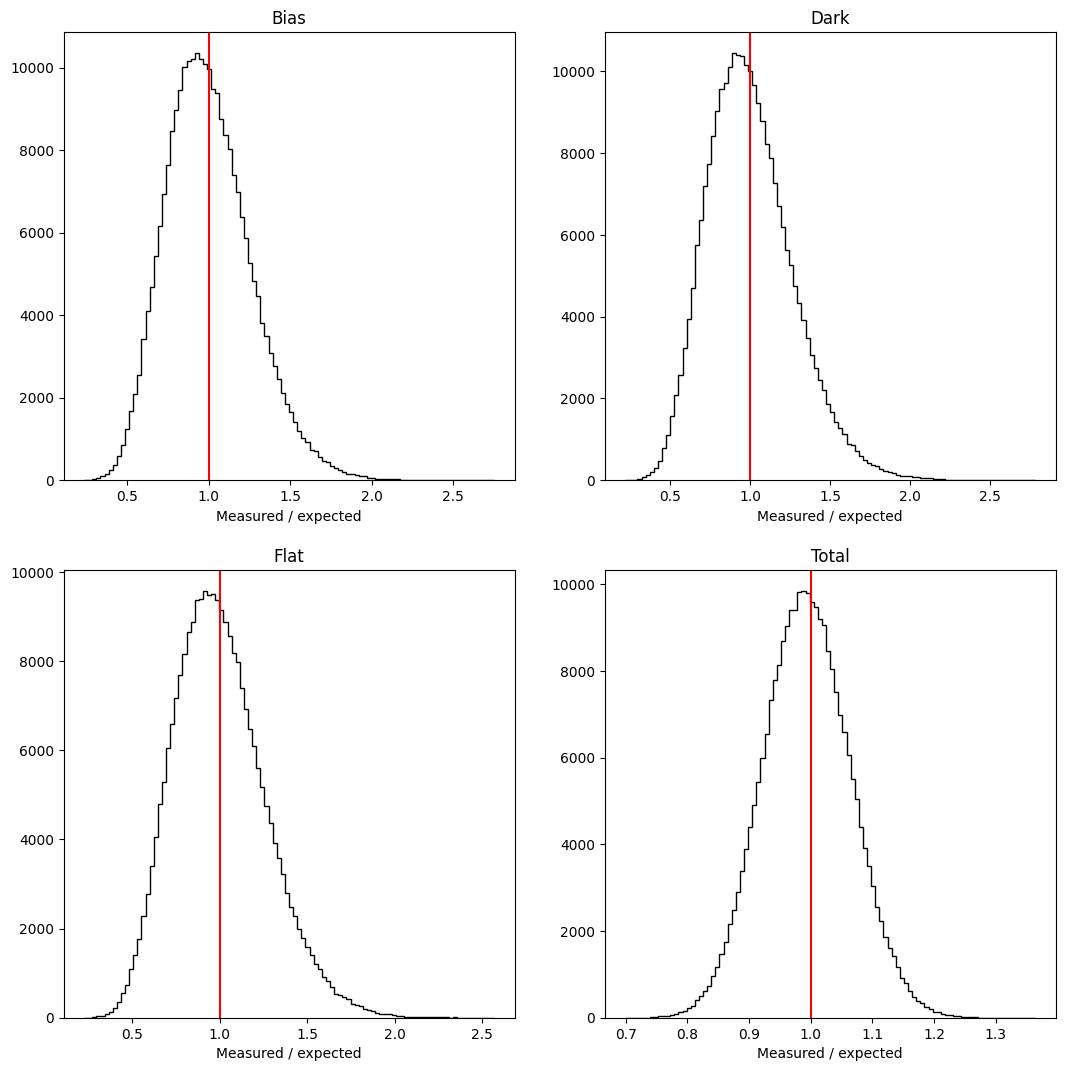

In [20]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12.8, 12.8),
    )

axes[0, 0].set_title('Bias')
axes[0, 0].hist(np.mean(bias_vars / true_bias_var, axis=0).flatten(),
        bins=100,
        histtype='step',
        color='k',
        )

axes[0, 1].set_title('Dark')
axes[0, 1].hist(np.mean(dark_vars / true_dark_var, axis=0).flatten(),
        bins=100,
        histtype='step',
        color='k',
        )

axes[1, 0].set_title('Flat')
axes[1, 0].hist(np.mean(flat_vars / effective_flat_var, axis=0).flatten(),
        bins=100,
        histtype='step',
        color='k',
        )

axes[1, 1].set_title('Total')
axes[1, 1].hist((empirical_err / measured_err).flatten(),
        bins=100,
        histtype='step',
        color='k',
        )

for ax in axes.flatten():
    ax.axvline(1, c='r', ls='-')
    ax.set_xlabel('Measured / expected')

plt.show()

Clearly, `opticam` is correctly propagating the errors from each calibration. However, this doesn't prove that the calibrations have actually been applied correctly. To verify this, we can check that the mean flux of the calibrated images is close to the expected value:

In [21]:
print(np.mean(calibrated_images / science_flux))

0.9999779237287508


In [22]:
assert np.isclose(np.mean(calibrated_images / science_flux), 1., rtol=0.01, atol=0)

Another reassuring result! Comparing the calibrated fluxes graphically:

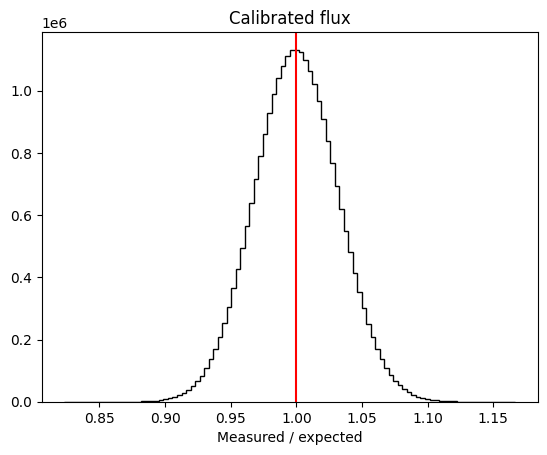

In [23]:
fig, ax = plt.subplots()

ax.hist(
    calibrated_images.flatten() / science_flux,
    bins=100,
    histtype='step',
    color='k',
    )

ax.axvline(1, c='r')
ax.set_xlabel('Measured / expected')
ax.set_title('Calibrated flux')

plt.show()

We can see that, unsurprisingly, the calibrated fluxes follow a Gaussian distribution centred on the expected value.

That concludes this demonstration of `opticam`'s calibration error propagation.